# Hermite Data Interpolation
From Macedo:


For the purpose of fitting an implicitly-defined hypersurface to given Hermite data  
$\{(x_i, n_i)\}_{i=1}^N \subset \mathbb{R}^n \times \mathbb{S}^{n-1}$,

we seek a function $f : \mathbb{R}^n \rightarrow \mathbb{R}$ satisfying both

$f(x_i) = 0
\quad \text{and} \quad
\nabla f(x_i) = n_i,$

for each $i = 1, \ldots, N$.

Our search will take place in a suitable subspace $\mathcal{H} \subset C^1(\mathbb{R}^n)$,
where $C^1(\mathbb{R}^n)$ denotes the space of continuously differentiable scalar-valued functions on $\mathbb{R}^n$.

In approximation theory, this problem is classified as **multivariate first-order Hermite interpolation**, which is a particular case of **Hermite–Birkhoff interpolation**.

> We are primarily interesting in the subspace $\mathcal{H}$ consisting of second order polynomials.

Resulting in the following optimization problem:

$f(x) = x^TAx + b^tx + c$ whit $\nabla f(x) = 2Ax + b$

s.t.

$f(x_i) = 0$ and $\nabla f(x_i) = n_i$

_comment: i think there should be a closed form solution here if we do a coordinate transfer to a linear space (i.e. rewrite it to $M \theta \approx y$)_

### Constructing $M$
Per sample we have $(x, y, z)$ with normals $n = (n_x, n_y, n_z)$
---

#### Unknown Parameters (10 total)

Parameter vector:

$$
\theta =
[a_{11}, a_{22}, a_{33},
 a_{12}, a_{13}, a_{23},
 b_1, b_2, b_3,
 c]^T
$$

Matrix A and vector b:

$$
A =
\begin{bmatrix}
a_{11} & a_{12} & a_{13} \\
a_{12} & a_{22} & a_{23} \\
a_{13} & a_{23} & a_{33}
\end{bmatrix}
$$

$$
b =
\begin{bmatrix}
b_1 \\
b_2 \\
b_3
\end{bmatrix}
$$

---

This gives four linear equation:

$$
[x^2,\; y^2,\; z^2,\; 2xy,\; 2xz,\; 2yz,\; x,\; y,\; z,\; 1] \; \theta = 0
$$
$$
[2x,\; 0,\; 0,\; 2y,\; 2z,\; 0,\; 1,\; 0,\; 0,\; 0] \; \theta = n_x
$$
$$
[0,\; 2y,\; 0,\; 2x,\; 0,\; 2z,\; 0,\; 1,\; 0,\; 0] \; \theta = n_y
$$
$$
[0,\; 0,\; 2z,\; 0,\; 2x,\; 2y,\; 0,\; 0,\; 1,\; 0] \; \theta = n_z
$$

---

Stack all equations to get the final linear system:

$$
M \theta \approx y
$$

In [217]:
import numpy as np
import matplotlib.pyplot as plt

def build_system_quadric(points, gradients):
    """
    Build the linear least-squares system for fitting an implicit quadric

        f(x) = x^T A x + b^T x + c,   with A symmetric,

    to Hermite data with (non-unit) gradient vectors:

        f(p_i) = 0
        ∇f(p_i) = g_i

    Unknown vector (10):
        theta = [a11,a22,a33,a12,a13,a23,b1,b2,b3,c]^T

    Returns:
        M: (4N, 10)
        y: (4N,)
    """
    P = np.asarray(points, dtype=float)
    G = np.asarray(gradients, dtype=float)
    rows = []
    rhs = []

    for (x, y0, z), (gx, gy, gz) in zip(P, G):
        # f(x)=0 row: [x^2, y^2, z^2, 2xy, 2xz, 2yz, x, y, z, 1] theta = 0
        row_f = np.array([x*x, y0*y0, z*z, 2*x*y0, 2*x*z, 2*y0*z, x, y0, z, 1.0])
        rows.append(row_f)
        rhs.append(0.0)

        # ∇f(x)=2Ax+b = g
        # x-component
        row_gx = np.array([2*x, 0.0, 0.0, 2*y0, 2*z, 0.0, 1.0, 0.0, 0.0, 0.0])
        rows.append(row_gx)
        rhs.append(gx)

        # y-component
        row_gy = np.array([0.0, 2*y0, 0.0, 2*x, 0.0, 2*z, 0.0, 1.0, 0.0, 0.0])
        rows.append(row_gy)
        rhs.append(gy)

        # z-component
        row_gz = np.array([0.0, 0.0, 2*z, 0.0, 2*x, 2*y0, 0.0, 0.0, 1.0, 0.0])
        rows.append(row_gz)
        rhs.append(gz)

    M = np.vstack(rows)
    y = np.asarray(rhs, dtype=float)

    return M, y

In [218]:
def solve_ls_qr(M, y):
    """
    Solve min ||M theta - y||_2 using numpy lstsq
    """
    theta, _, rank, s = np.linalg.lstsq(M, y)
    return theta, rank, s

In [219]:
def quadric_fn_from_theta(theta):
    """
    theta = [a11,a22,a33,a12,a13,a23,b1,b2,b3,c]
    and f(x,y,z) = a11 x^2 + a22 y^2 + a33 z^2
                + 2 a12 x y + 2 a13 x z + 2 a23 y z
                + b1 x + b2 y + b3 z + c
    """
    theta = np.asarray(theta, dtype=float).ravel()
    a11,a22,a33,a12,a13,a23,b1,b2,b3,c = theta

    def f(x, y, z):
        return (
            a11*x*x + a22*y*y + a33*z*z
            + 2*a12*x*y + 2*a13*x*z + 2*a23*y*z
            + b1*x + b2*y + b3*z + c
        )

    return f

In [220]:
def quadric_grad_from_theta(theta):
    """
    theta = [a11,a22,a33,a12,a13,a23,b1,b2,b3,c]
    f(x,y,z) = a11 x^2 + a22 y^2 + a33 z^2
             + 2 a12 x y + 2 a13 x z + 2 a23 y z
             + b1 x + b2 y + b3 z + c

    """
    theta = np.asarray(theta, dtype=float).ravel()
    a11, a22, a33, a12, a13, a23, b1, b2, b3, c = theta  # c unused in gradient

    def grad_f(x, y, z):
        x = np.asarray(x)
        y = np.asarray(y)
        z = np.asarray(z)

        dfdx = 2*a11*x + 2*a12*y + 2*a13*z + b1
        dfdy = 2*a12*x + 2*a22*y + 2*a23*z + b2
        dfdz = 2*a13*x + 2*a23*y + 2*a33*z + b3

        return np.stack([dfdx, dfdy, dfdz], axis=-1)

    return grad_f

In [221]:
def add_awgn(points,
             gradients=None,
             sigma_points=0.01,
             sigma_gradients=0.01,
             seed=None):
    """
    Add AWGN to points and optionally gradients.

    Parameters:
        points: (N,3)
        gradients: (N,3) or None
        sigma_points: std dev for point noise
        sigma_gradients: std dev for gradient noise
        seed: for reproducibility

    Returns:
        noisy_points
        noisy_gradients (or None)
    """

    rng = np.random.default_rng(seed)

    noisy_points = points + rng.normal(
        loc=0.0,
        scale=sigma_points,
        size=points.shape
    )

    if gradients is not None:
        noisy_gradients = gradients + rng.normal(
            loc=0.0,
            scale=sigma_gradients,
            size=gradients.shape
        )
    else:
        noisy_gradients = None

    return noisy_points, noisy_gradients

In [222]:
def plot_implicit(fn, bbox=(-3, 3),
                  n_grid=120, n_slices=20,
                  points=None,
                  normals=None):
    
    xmin, xmax = bbox
    ymin, ymax = bbox
    zmin, zmax = bbox

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")

    A = np.linspace(xmin, xmax, n_grid)
    B = np.linspace(xmin, xmax, n_slices)
    A1, A2 = np.meshgrid(A, A)

    # --- XY slices ---
    for z0 in B:
        X, Y = A1, A2
        F = fn(X, Y, z0)
        ax.contour(X, Y, F + z0, levels=[z0], zdir="z")

    # --- XZ slices ---
    for y0 in B:
        X, Z = A1, A2
        F = fn(X, y0, Z)
        ax.contour(X, F + y0, Z, levels=[y0], zdir="y")

    # --- YZ slices ---
    for x0 in B:
        Y, Z = A1, A2
        F = fn(x0, Y, Z)
        ax.contour(F + x0, Y, Z, levels=[x0], zdir="x")

    # --- Plot reference points ---
    if points is not None:
        ax.scatter(points[:, 0],
                   points[:, 1],
                   points[:, 2],
                   color="red",
                   s=15,
                   label="Reference points")

    # --- Plot normals (optional) ---
    if points is not None and normals is not None:
        ax.quiver(points[:, 0],
                  points[:, 1],
                  points[:, 2],
                  normals[:, 0],
                  normals[:, 1],
                  normals[:, 2],
                  length=0.2,
                  color="black")

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)

    ax.legend()
    plt.tight_layout()
    plt.show()

In [223]:
def plot_error_slice(f_true,
                     f_interp,
                     bbox=(-2, 2),
                     resolution=200,
                     slice_axis='z',
                     slice_value=0.0):
    """
    Plots error = f_interp - f_true on a 2D slice.

    slice_axis: 'x', 'y', or 'z'
    """

    xmin, xmax = bbox
    A = np.linspace(xmin, xmax, resolution)
    X, Y = np.meshgrid(A, A)

    if slice_axis == 'z':
        Z = slice_value
        E = f_interp(X, Y, Z) - f_true(X, Y, Z)
        xlabel, ylabel = "x", "y"

    elif slice_axis == 'y':
        Y_fixed = slice_value
        E = f_interp(X, Y_fixed, Y) - f_true(X, Y_fixed, Y)
        xlabel, ylabel = "x", "z"

    elif slice_axis == 'x':
        X_fixed = slice_value
        E = f_interp(X_fixed, X, Y) - f_true(X_fixed, X, Y)
        xlabel, ylabel = "y", "z"

    else:
        raise ValueError("slice_axis must be 'x', 'y', or 'z'")

    plt.figure(figsize=(6,5))
    im = plt.imshow(
        E,
        extent=[xmin, xmax, xmin, xmax],
        origin="lower",
        aspect="equal"
    )
    plt.colorbar(im, label="Interpolation Error")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f"Error slice at {slice_axis} = {slice_value}")
    plt.tight_layout()
    plt.show()

In [224]:
def rms_vs_z_slices(f, g, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5), zlim=(-1.5, 1.5), n=300, band_tau=None):
    """
    Compute RMS of (f-g) on each z-slice and plot RMS vs z.

    If band_tau is not None, RMS is computed only where |g| < band_tau on that slice
    """
    x = np.linspace(xlim[0], xlim[1], n)
    y = np.linspace(ylim[0], ylim[1], n)
    z = np.linspace(zlim[0], zlim[1])
    X, Y = np.meshgrid(x, y, indexing="xy")

    rms = np.empty_like(z)

    for i, z0 in enumerate(z):
        Z = np.full_like(X, z0)
        F = f(X, Y, Z)
        G = g(X, Y, Z)
        D = F - G

        if band_tau is None:
            rms[i] = np.sqrt(np.mean(D**2))
        else:
            m = np.abs(G) < band_tau
            rms[i] = np.sqrt(np.mean(D[m]**2)) if np.any(m) else np.nan

    plt.figure()
    plt.plot(z, rms, marker="o")
    plt.xlabel("z")
    plt.ylabel("RMS(f-g) on slice")
    plt.grid(True)
    plt.title("RMS error vs z")
    plt.show()

    return z, rms

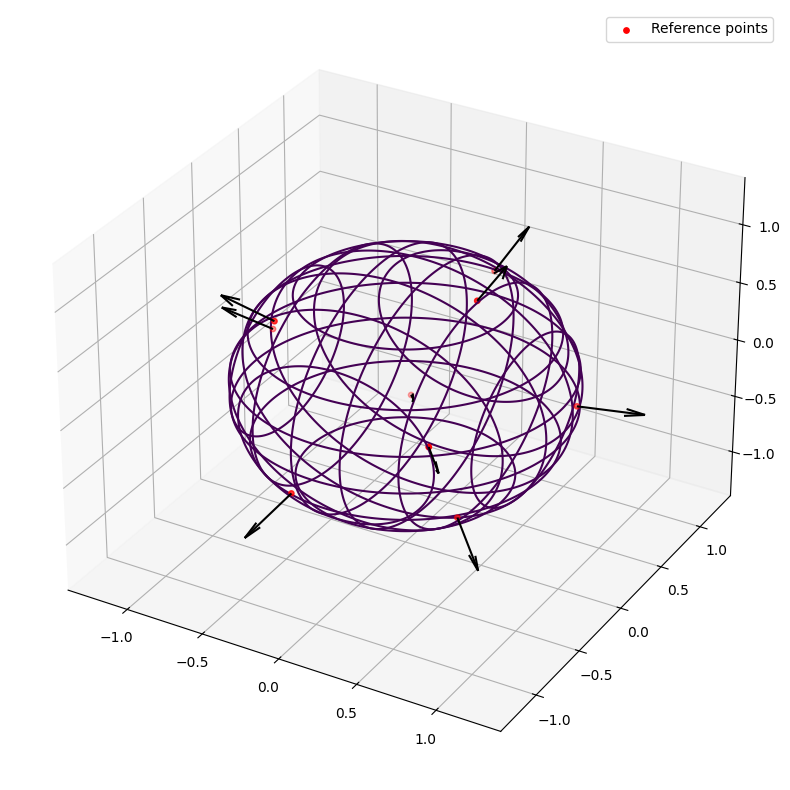

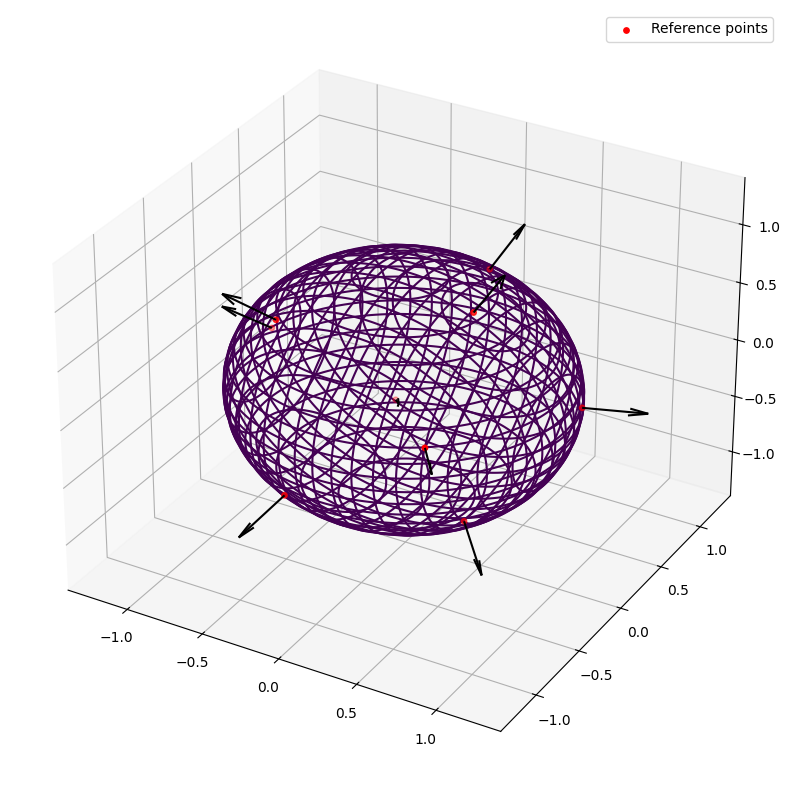

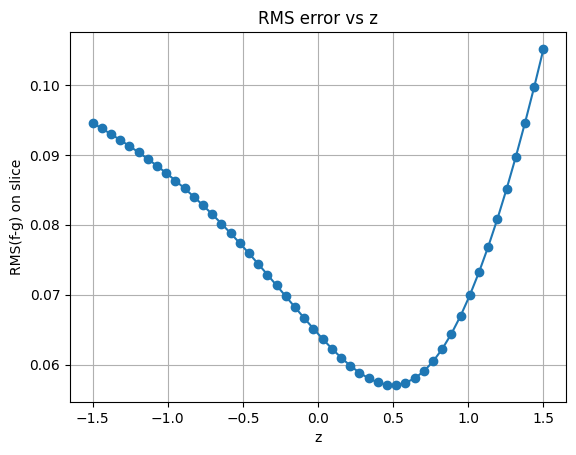

(array([-1.5       , -1.43877551, -1.37755102, -1.31632653, -1.25510204,
        -1.19387755, -1.13265306, -1.07142857, -1.01020408, -0.94897959,
        -0.8877551 , -0.82653061, -0.76530612, -0.70408163, -0.64285714,
        -0.58163265, -0.52040816, -0.45918367, -0.39795918, -0.33673469,
        -0.2755102 , -0.21428571, -0.15306122, -0.09183673, -0.03061224,
         0.03061224,  0.09183673,  0.15306122,  0.21428571,  0.2755102 ,
         0.33673469,  0.39795918,  0.45918367,  0.52040816,  0.58163265,
         0.64285714,  0.70408163,  0.76530612,  0.82653061,  0.8877551 ,
         0.94897959,  1.01020408,  1.07142857,  1.13265306,  1.19387755,
         1.25510204,  1.31632653,  1.37755102,  1.43877551,  1.5       ]),
 array([0.09457696, 0.09378158, 0.09296771, 0.09212939, 0.09126121,
        0.09035832, 0.08941645, 0.08843193, 0.08740166, 0.08632319,
        0.0851947 , 0.08401503, 0.08278377, 0.08150124, 0.08016859,
        0.07878787, 0.07736214, 0.07589551, 0.07439336, 0.072862

In [229]:
# --- ground truth implicit: f(x,y,z)=x^2+y^2+z^2-1=0
def sphere_f(x, y, z):
    return x*x + y*y + z*z - 1.0

def sphere_grad(p):
    # ∇f = [2x, 2y, 2z]
    return 2.0 * p

# --- sample points on the sphere with a Fibonacci lattice
def fibonacci_sphere(n=400):
    i = np.arange(n)
    phi = (1 + np.sqrt(5)) / 2
    theta = 2*np.pi*i/phi
    z = 1 - 2*(i + 0.5)/n
    r = np.sqrt(np.clip(1 - z*z, 0, 1))
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.stack([x, y, z], axis=1)

points = fibonacci_sphere(n=9)
gradients = sphere_grad(points)  

noisy_points, noisy_gradients = add_awgn(points=points, gradients=gradients, sigma_points=0.05, sigma_gradients=0.05)

M, y = build_system_quadric(points, gradients)
theta, rank, s = solve_ls_qr(M, y)
f_quadric = quadric_fn_from_theta(theta)
plot_implicit(f_quadric, bbox=(-1.4, 1.4), n_grid=140, n_slices=10, points=points, normals=gradients)

M_noisy, y_noisy = build_system_quadric(noisy_points, noisy_gradients)
theta_noisy, _, _ = solve_ls_qr(M_noisy, y_noisy)
f_quadric_noisy = quadric_fn_from_theta(theta_noisy)
plot_implicit(f_quadric_noisy, bbox=(-1.4, 1.4), n_grid=140, n_slices=25, points=noisy_points, normals=noisy_gradients)

rms_vs_z_slices(sphere_f, f_quadric_noisy, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5), zlim=(-1.5, 1.5), n=300, band_tau=None)

[ 0.01616938  0.00718639  0.1796598  -0.01077959 -0.05389794  0.03593196
 -0.27143667  0.18095778  0.90478891 -0.09227549]


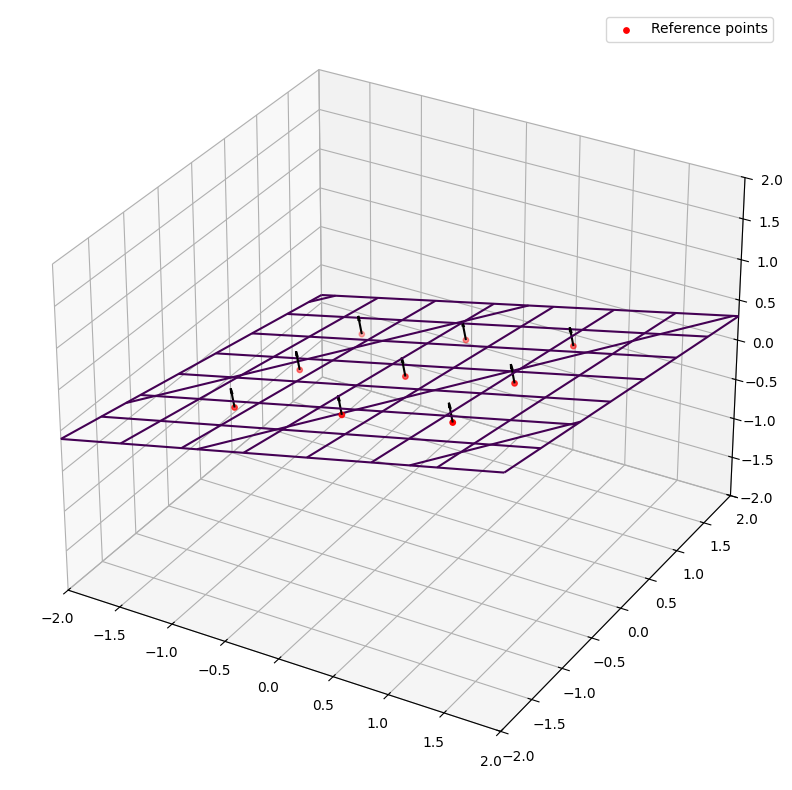

In [226]:
def make_plane_grid(N=20, a=0.3, b=-0.2, c=0.1):
    """
    Creates N x N grid points on plane:
        z = a x + b y + c

    Returns:
        points: (N^2, 3)
        gradients: (N^2, 3)
    """

    points = []
    
    # constant normal of the plane
    normal = np.array([-a, -b, 1.0])
    normal = normal / np.linalg.norm(normal)

    xs = np.linspace(-1, 1, N)
    ys = np.linspace(-1, 1, N)

    for x in xs:
        for y in ys:
            z = a*x + b*y + c
            points.append([x, y, z])

    points = np.array(points)
    gradients = np.tile(normal, (points.shape[0], 1))

    return points, gradients


points_plane, gradients_plane = make_plane_grid(N=3)
M, y = build_system_quadric(points_plane, gradients_plane)
theta, rank, s = solve_ls_qr(M, y)
print(theta)
f_quadric = quadric_fn_from_theta(theta)
plot_implicit(f_quadric, bbox=(-2, 2), n_grid=140, n_slices=8, points=points_plane, normals=gradients_plane)